In [4]:
days_holding = "7"
days_momentum = "30"
days_skip = "7"
max_positions = "20"
fee_per_leg = "0.0005"
min_market_cap_rank = "100"
max_market_cap_rank = "500"
min_momentum_decile = "10"
min_price = "0.0001"
min_volume = "1_000_000"
days_trend_filter = "2"
min_frog_percentage = "-100"
year = "2026"
benchmark = "bitcoin"

In [5]:
days_holding_P = int(days_holding)
days_momentum_P = int(days_momentum)
days_skip_P = int(days_skip)
days_trend_filter_P = int(days_trend_filter)
max_positions_P = int(max_positions)
min_market_cap_rank_P = int(min_market_cap_rank)
max_market_cap_rank_P = int(max_market_cap_rank)
min_momentum_decile_P = int(min_momentum_decile)
min_frog_percentage_P = int(min_frog_percentage)
min_price_P = float(min_price)
min_volume_P = int(min_volume)
fee_per_leg_P = float(fee_per_leg)
year_P = int(year)


ANNUALIZATION_FACTOR = 365

import polars as pl
import numpy as np

df = (
    pl.read_parquet("cmc-usd-1d-2020-2026.parquet")
    .sort(["symbol", "ts"])
    .filter(pl.col("symbol").is_in(["terra-luna", "ftx-token"]).not_())
    .with_columns(
        fwd_ret_1d=(
            pl.col("close").shift(-1).over("symbol") / pl.col("close") - 1
        ).clip(-1, 5),
        fwddays=(pl.col("ts").shift(-1).over("symbol") - pl.col("ts")).dt.total_days(),
        mom=pl.col("close").shift(days_skip_P).over("symbol")
        / pl.col("close").shift(days_momentum_P).over("symbol")
        - 1,
        momdays=(
            pl.col("ts").shift(days_skip_P).over("symbol")
            - pl.col("ts").shift(days_momentum_P).over("symbol")
        ).dt.total_days(),
        mc_rank=pl.col("market_cap").rank(descending=True, method="ordinal").over("ts"),
        direction=pl.when(pl.col('open') < pl.col('close')).then(1).otherwise(-1),
        #trend=pl.col("close").ewm_mean(span=days_trend_filter_P, adjust=True).over('symbol'),
        trend=pl.col("close").rolling_mean(days_trend_filter_P).over('symbol'),

    )
    .filter(
        (pl.col("mom").is_not_null())
        & (pl.col("fwddays") == 1)
        & (pl.col("momdays") == days_momentum_P - days_skip_P)
    )
    .with_columns(
        mom_q=pl.col("mom")
        .qcut(10, labels=[str(i) for i in range(1, 11)], allow_duplicates=True)
        .over("ts"),
    )
    .with_columns(
        mask_mom=pl.when(
            (pl.col("mc_rank") >= min_market_cap_rank_P)
            & (pl.col("mc_rank") <= max_market_cap_rank_P)
            & (pl.col("mom_q").cast(pl.Utf8).cast(pl.Int64) >= min_momentum_decile_P)
            #& (pl.col("close") >= min_price_P)
            & (pl.col("mom") > 0)
            #& ((pl.col('direction').rolling_sum(days_momentum_P) / days_momentum_P) > (min_frog_percentage_P / 100.0))
            & (pl.col('close') > pl.col('trend'))
            & (pl.col('volume') > min_volume_P)
        )
        .then(pl.col("mom"))
        .otherwise(
            None
        )  # Coins outside top get None, making them invisible to the next ranking step
    )
    .with_columns(
        rank=pl.col("mask_mom").rank(descending=True, method="ordinal").over("ts")
    )
    # 7. SELECTION: Binary mask for the Top momentum coins (from the Top universe)
    .with_columns(
        is_selected=pl.when(pl.col("rank") <= max_positions_P).then(1).otherwise(0)
    )
    # 8. SUB-WEIGHTING
    .with_columns(sub_weight=pl.col("is_selected") / max_positions_P)
    # 9. J&T OVERLAP: Aggregate weight across 30 active sub-portfolios
    .with_columns(
        total_weight=(
            pl.col("sub_weight").rolling_sum(window_size=days_holding_P).over("symbol")
            / days_holding_P
        )
    )
)

if df.height == 0:
    print("no trades")
    raise 1

# --- Performance Calculation ---
strategy_returns = (
    df.filter(pl.col("ts").dt.year() >= year_P)
    .group_by("ts")
    .agg(strategy_ret_1d=(pl.col("total_weight") * pl.col("fwd_ret_1d")).sum())
    .sort("ts")
)

daily_fee_drag = (fee_per_leg_P * 2) / days_holding_P
strategy_results = strategy_returns.with_columns(
    net_daily_ret=pl.col("strategy_ret_1d") - daily_fee_drag
)

total_days = strategy_results.height
cumulative_return = (strategy_results["net_daily_ret"] + 1).product()
cagr = (cumulative_return ** (ANNUALIZATION_FACTOR / total_days)) - 1 if total_days > 0 and cumulative_return > 0 else float('nan')

mean_net_ret = strategy_results["net_daily_ret"].mean()
downside_deviation = strategy_results.filter(pl.col("net_daily_ret") < 0)[
    "net_daily_ret"
].std()
sortino_ratio = (mean_net_ret / downside_deviation) * np.sqrt(ANNUALIZATION_FACTOR) if (downside_deviation is not None and downside_deviation != 0) else float('nan')
# --- 10. Advanced Risk Metrics & Benchmark Comparison ---

# Extract ref's 1-day forward returns from the main DataFrame to use as the benchmark
ref_benchmark = df.filter(
    (pl.col("symbol") == benchmark) & (pl.col("ts").dt.year() >= year_P)
).select(ts=pl.col("ts"), ref_ret_1d=pl.col("fwd_ret_1d"))

# Join ref returns to strategy returns
strategy_results = strategy_results.join(ref_benchmark, on="ts", how="left")

# Calculate Active Returns (Strategy Net Return - ref Return)
strategy_results = strategy_results.with_columns(
    active_ret=pl.col("net_daily_ret") - pl.col("ref_ret_1d")
)

# --- MAX DRAWDOWN CALCULATION ---
# Strategy Drawdown
strategy_results = (
    strategy_results.with_columns(cum_return=(pl.col("net_daily_ret") + 1).cum_prod())
    .with_columns(rolling_peak=pl.col("cum_return").cum_max())
    .with_columns(drawdown=(pl.col("cum_return") / pl.col("rolling_peak")) - 1)
)
strat_mdd = strategy_results["drawdown"].min()

# ref Drawdown
strategy_results = (
    strategy_results.with_columns(ref_cum_return=(pl.col("ref_ret_1d") + 1).cum_prod())
    .with_columns(ref_rolling_peak=pl.col("ref_cum_return").cum_max())
    .with_columns(
        ref_drawdown=(pl.col("ref_cum_return") / pl.col("ref_rolling_peak")) - 1
    )
)
ref_mdd = strategy_results["ref_drawdown"].min()

# --- INFORMATION RATIO & BENCHMARK CAGR ---
# ref CAGR
ref_total_days = strategy_results["ref_ret_1d"].drop_nulls().len()
ref_cum_return_final = (strategy_results["ref_ret_1d"].drop_nulls() + 1).product()
if ref_total_days == 0:
    print(f"WARNING: Benchmark '{benchmark}' not found in strategy results. Check benchmark symbol or year parameter.")
ref_cagr = (ref_cum_return_final ** (ANNUALIZATION_FACTOR / ref_total_days)) - 1 if ref_total_days > 0 else float('nan')

# Information Ratio
mean_active_ret = strategy_results["active_ret"].mean()
tracking_err = strategy_results["active_ret"].std()
information_ratio = (mean_active_ret / tracking_err) * np.sqrt(ANNUALIZATION_FACTOR) if (tracking_err is not None and tracking_err != 0) else float('nan')
# --- 11. Position Sizing: The Kelly Criterion ---

# Using the continuous approximation for Kelly: f = Expected Excess Return / Variance
# Assuming the Risk-Free Rate = 0 (standard in native crypto strategies)
daily_variance = strategy_results["net_daily_ret"].var()

# We annualize both the mean and the variance
annualized_mean_ret = mean_net_ret * ANNUALIZATION_FACTOR
annualized_variance = daily_variance * ANNUALIZATION_FACTOR

# Full Kelly Fraction
kelly_fraction = annualized_mean_ret / annualized_variance if annualized_variance != 0 else float('nan')

def _fmt(val, fmt_spec):
    """Format a value safely, returning 'N/A' for None or NaN."""
    if val is None:
        return 'N/A'
    try:
        if np.isnan(val):
            return 'N/A'
    except (TypeError, ValueError):
        pass
    return format(val, fmt_spec)

# Half Kelly (The institutional standard for real-world trading)
half_kelly = kelly_fraction / 2 if kelly_fraction is not None and not (isinstance(kelly_fraction, float) and np.isnan(kelly_fraction)) else float('nan')

# --- UPDATED FINAL PRINT OUT ---
print(f"--- Strategy vs Buy-and-Hold ref (Since {year_P}) ---")
print(f"Strategy CAGR:     {_fmt(cagr, '.2%')}")
print(f"{benchmark.upper()} BnH CAGR:      {_fmt(ref_cagr, '.2%')}\n")

print(f"Strategy MDD:      {_fmt(strat_mdd, '.2%')}")
print(f"{benchmark.upper()} BnH MDD:       {_fmt(ref_mdd, '.2%')}\n")

print(f"Information Ratio: {_fmt(information_ratio, '.2f')}")
print(f"Sortino Ratio:     {_fmt(sortino_ratio, '.2f')}\n")

print(f"--- Recommended Allocation ---")
print(f"Full Kelly:        {_fmt(kelly_fraction, '.2%')}")
print(f"Half Kelly:        {_fmt(half_kelly, '.2%')}")

--- Strategy vs Buy-and-Hold ref (Since 2026) ---
Strategy CAGR:     -1.99%
BITCOIN BnH CAGR:      -22.19%

Strategy MDD:      -4.09%
BITCOIN BnH MDD:       -35.31%

Information Ratio: 0.16
Sortino Ratio:     -1.18

--- Recommended Allocation ---
Full Kelly:        -1421.74%
Half Kelly:        -710.87%


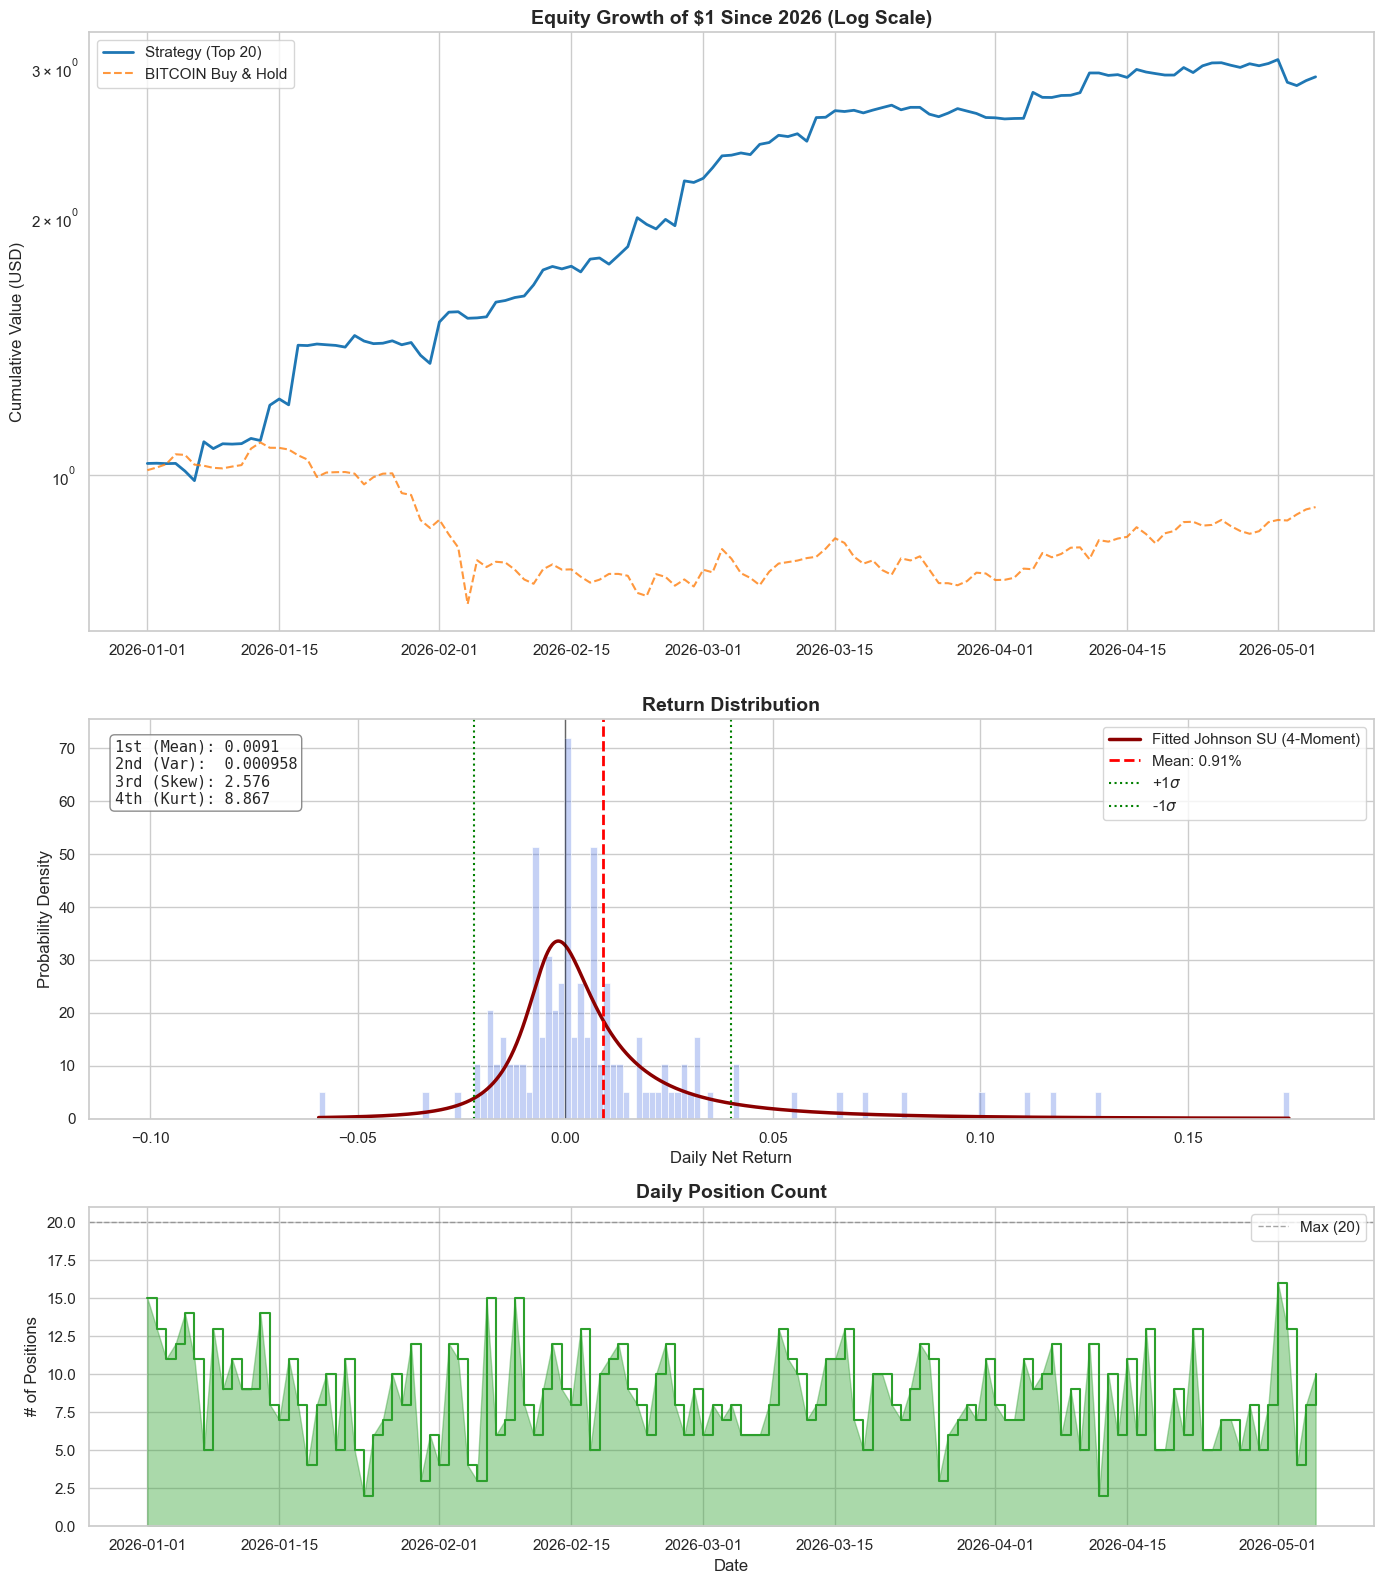

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# --- 1. Prepare Data ---
dates = strategy_results["ts"].to_numpy()
strat_equity = (
    (strategy_results["net_daily_ret"].fill_null(0) + 1).cum_prod().to_numpy()
)
ref_equity = (strategy_results["ref_ret_1d"].fill_null(0) + 1).cum_prod().to_numpy()
strat_rets = strategy_results["net_daily_ret"].drop_nulls().to_numpy()
daily_position_count = (
    df.filter(pl.col("ts").dt.year() >= year_P)
    .group_by("ts")
    .agg(pos_count=pl.col("is_selected").sum())
    .sort("ts")
)

# --- 2. Calculate Statistical Moments ---
mean_ret = np.mean(strat_rets)
std_ret = np.std(strat_rets)
variance = np.var(strat_rets)  # 2nd Moment
skewness = stats.skew(strat_rets)  # 3rd Moment
# We use Fisher’s definition (Excess Kurtosis), where Normal = 0
excess_kurtosis = stats.kurtosis(strat_rets)  # 4th Moment

# --- 3. Fit Johnson SU Distribution (Matches all 4 Moments) ---
# This is the "Gold Standard" for fitting financial return distributions
# a, b are shape parameters (skew/kurtosis), loc is center, scale is width
a_fit, b_fit, loc_fit, scale_fit = stats.johnsonsu.fit(strat_rets)

# --- 4. Plotting ---
sns.set_theme(style="whitegrid")
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(14, 16), gridspec_kw={"height_ratios": [1.5, 1, 0.8]}
)

# --- Plot 1: Log Equity Curve ---
ax1.plot(
    dates,
    strat_equity,
    label=f"Strategy (Top {max_positions})",
    color="#1f77b4",
    linewidth=2,
)
ax1.plot(
    dates,
    ref_equity,
    label=f"{benchmark.upper()} Buy & Hold",
    color="#ff7f0e",
    linestyle="--",
    alpha=0.8,
)
ax1.set_yscale("log")
ax1.set_title(
    f"Equity Growth of $1 Since {year_P} (Log Scale)", fontsize=14, fontweight="bold"
)
ax1.set_ylabel("Cumulative Value (USD)")
ax1.legend(loc="upper left")

# --- Plot 2: Distribution with 4-Moment Fitted Curve ---
# Using more bins to show the "peaky" nature (Kurtosis)
sns.histplot(strat_rets, bins=150, stat="density", color="royalblue", alpha=0.3, ax=ax2)

# Generate fitted Johnson SU PDF
x_axis = np.linspace(strat_rets.min(), strat_rets.max(), 1000)
johnson_pdf = stats.johnsonsu.pdf(x_axis, a_fit, b_fit, loc_fit, scale_fit)
ax2.plot(
    x_axis,
    johnson_pdf,
    color="darkred",
    linewidth=2.5,
    label="Fitted Johnson SU (4-Moment)",
)

# Reference lines
ax2.axvline(0, color="black", linestyle="-", linewidth=1, alpha=0.5)
ax2.axvline(
    mean_ret, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_ret:.2%}"
)
ax2.axvline(
    mean_ret + std_ret, color="green", linestyle=":", linewidth=1.5, label="+1$\sigma$"
)
ax2.axvline(
    mean_ret - std_ret, color="green", linestyle=":", linewidth=1.5, label="-1$\sigma$"
)

# Stats box with all 4 moments
stats_text = (
    f"1st (Mean): {mean_ret:.4f}\n"
    f"2nd (Var):  {variance:.6f}\n"
    f"3rd (Skew): {skewness:.3f}\n"
    f"4th (Kurt): {excess_kurtosis:.3f}"
)
props = dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray")
ax2.text(
    0.02,
    0.95,
    stats_text,
    transform=ax2.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=props,
    family="monospace",
)

ax2.set_title("Return Distribution", fontsize=14, fontweight="bold")
ax2.set_xlabel("Daily Net Return")
ax2.set_ylabel("Probability Density")
ax2.legend(loc="upper right")

# Zoom in slightly on the center to see the fit better, while keeping tails visible
ax2.set_xlim(mean_ret - 4 * std_ret, mean_ret + 6 * std_ret)

# --- Plot 3: Daily Position Count ---
ax3.fill_between(
    daily_position_count["ts"].to_numpy(),
    daily_position_count["pos_count"].to_numpy(),
    color="#2ca02c",
    alpha=0.4,
)
ax3.plot(
    daily_position_count["ts"].to_numpy(),
    daily_position_count["pos_count"].to_numpy(),
    color="#2ca02c",
    linewidth=1.5,
    drawstyle="steps-post",
)
ax3.axhline(
    y=max_positions_P,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label=f"Max ({max_positions_P})",
)
ax3.set_title("Daily Position Count", fontsize=14, fontweight="bold")
ax3.set_ylabel("# of Positions")
ax3.set_xlabel("Date")
ax3.legend(loc="upper right")
ax3.set_ylim(bottom=0)

plt.tight_layout()
plt.show()